In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

In [36]:
df_numerico = pd.read_csv("Wuppi convertido.csv")
df_numerico = df_numerico.drop(columns=["Unnamed: 0","Unnamed: 0.1"])
df_numerico.head(5)

,Administrador,Usuario,botón correcto,tiempo de interacción,mini juego,número de interacción,color presionado,dificultad,fecha,Juego,auto push,tiempo de lección,tiempo de sesión
0,2.0,3.0,1.0,5.399169,9.0,1.0,4.0,1.0,25/01/2024 09:26:42 a. m.,1.0,0.0,0.0,0.0
1,2.0,3.0,0.0,1.283400,9.0,2.0,1.0,1.0,25/01/2024 09:26:46 a. m.,1.0,0.0,0.0,0.0
2,2.0,3.0,1.0,2.700226,9.0,3.0,2.0,1.0,25/01/2024 09:26:48 a. m.,1.0,0.0,0.0,0.0
3,2.0,3.0,0.0,3.050262,9.0,4.0,2.0,1.0,25/01/2024 09:26:57 a. m.,1.0,0.0,0.0,0.0
4,2.0,3.0,0.0,4.750256,9.0,5.0,2.0,1.0,25/01/2024 09:26:58 a. m.,1.0,0.0,0.0,0.0


In [37]:
df_categorico = pd.read_csv("Wuppi_limpio.csv")
df_categorico = df_categorico.drop(columns=["Unnamed: 0"])
df_categorico.head(5)

,Administrador,Usuario,botón_correcto,tiempo_de_interacción,mini_juego,número_de_interacción,color_presionado,dificultad,fecha,Juego,auto_push,tiempo_de_lección,tiempo_de_sesión
0,nicolas,nicolas,1.0,5.399169,Despegue,1.0,blue,Episodio 1,25/01/2024 09:26:42 a. m.,Astro,0.0,0.0,0.0
1,nicolas,nicolas,0.0,1.283400,Despegue,2.0,violet,Episodio 1,25/01/2024 09:26:46 a. m.,Astro,0.0,0.0,0.0
2,nicolas,nicolas,1.0,2.700226,Despegue,3.0,green,Episodio 1,25/01/2024 09:26:48 a. m.,Astro,0.0,0.0,0.0
3,nicolas,nicolas,0.0,3.050262,Despegue,4.0,green,Episodio 1,25/01/2024 09:26:57 a. m.,Astro,0.0,0.0,0.0
4,nicolas,nicolas,0.0,4.750256,Despegue,5.0,green,Episodio 1,25/01/2024 09:26:58 a. m.,Astro,0.0,0.0,0.0


# Anova y Manova

### Tiempo de interacción

<Axes: title={'center': 'tiempo_de_interacción'}, xlabel='Juego'>

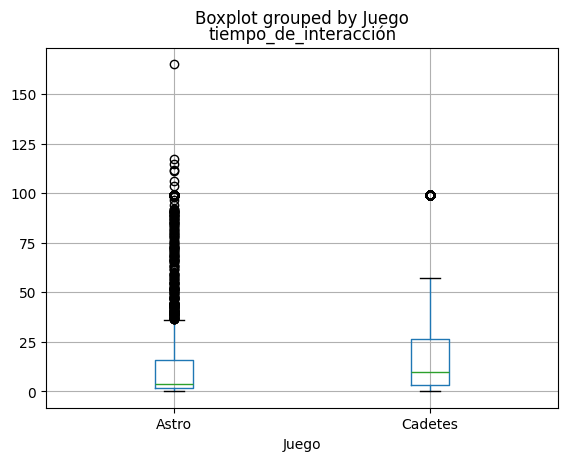

In [38]:
df_categorico.boxplot("tiempo_de_interacción", by="Juego")

In [40]:
mod = ols('tiempo_de_interacción ~ Juego', data=df_categorico).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

              df        sum_sq       mean_sq         F    PR(>F)
Juego        1.0  2.117495e+04  21174.953066  19.41033  0.000011
Residual  5863.0  6.396014e+06   1090.911557       NaN       NaN


### botón_correcto

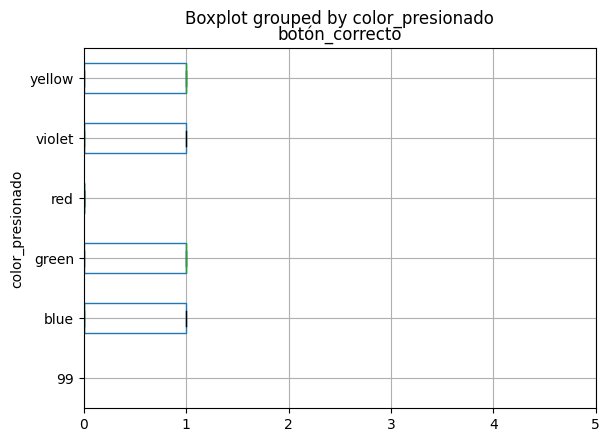

In [59]:
ax = df_categorico.boxplot("botón_correcto", by="color_presionado", vert=False)
ax = plt.gca()
ax.set_xlim([0, 5])  # ajusta estos valores según lo que necesites

plt.show()

In [42]:
mod = ols('botón_correcto ~ color_presionado', data=df_categorico).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                      df        sum_sq       mean_sq             F  PR(>F)
color_presionado     5.0  6.433570e+06  1.286714e+06  5.947586e+06     0.0
Residual          5859.0  1.267549e+03  2.163422e-01           NaN     NaN


### número_de_interacción

<Axes: title={'center': 'número_de_interacción'}, ylabel='dificultad'>

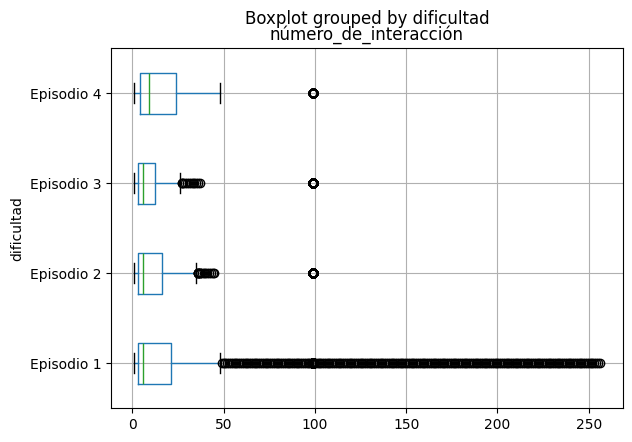

In [53]:
df_categorico.boxplot("número_de_interacción", by="dificultad", vert=False)

In [44]:
mod = ols('número_de_interacción ~ dificultad', data=df_categorico).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                df        sum_sq       mean_sq         F        PR(>F)
dificultad     3.0  1.719552e+05  57318.394828  33.84068  1.120169e-21
Residual    5861.0  9.927197e+06   1693.771937       NaN           NaN


### auto_push

In [85]:
Max=df_categorico["auto_push"].max()
Min=df_categorico["auto_push"].min()
Limites=[Min, Max]
print(Limites)
print(df_categorico["auto_push"].mean())

[np.float64(0.0), np.float64(1.0)]
0.009207161125319692


<Axes: title={'center': 'auto_push'}, ylabel='Juego'>

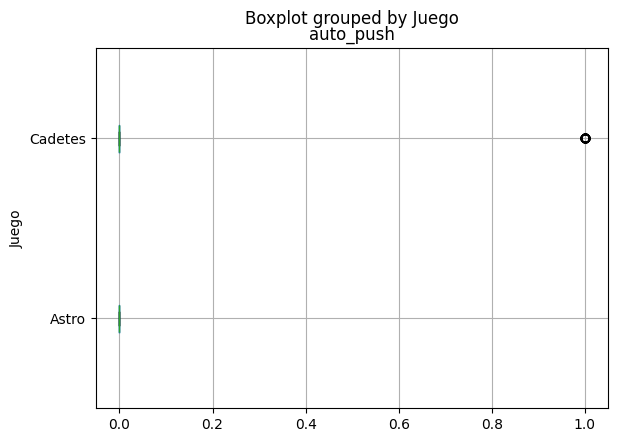

In [80]:
df_categorico.boxplot("auto_push", by="Juego", vert=False)


In [46]:
mod = ols('auto_push ~ Juego', data=df_categorico).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

              df     sum_sq   mean_sq           F        PR(>F)
Juego        1.0   0.914236  0.914236  101.926463  9.005291e-24
Residual  5863.0  52.588577  0.008970         NaN           NaN


### tiempo_de_lección

In [87]:
Max=df_categorico["tiempo_de_lección"].max()
Min=df_categorico["tiempo_de_lección"].min()
Limites=[Min, Max]
print(Limites)
print(df_categorico["tiempo_de_lección"].mean())

[np.float64(0.0), np.float64(781.3312)]
6.066631425592498


<Axes: title={'center': 'tiempo_de_lección'}, ylabel='dificultad'>

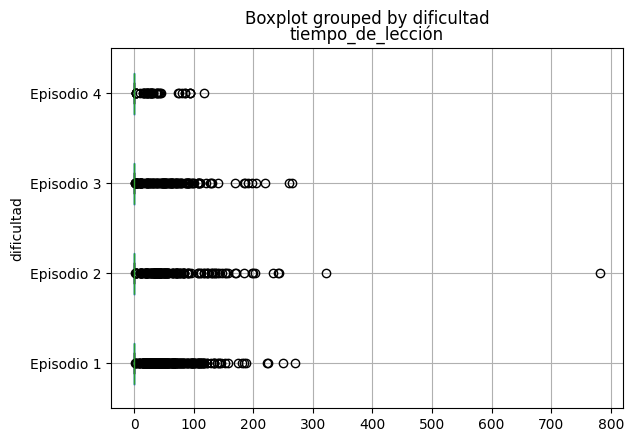

In [89]:
df_categorico.boxplot("tiempo_de_lección", by="dificultad", vert=False)



In [49]:
mod = ols('tiempo_de_lección ~ dificultad', data=df_categorico).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

                df        sum_sq      mean_sq         F    PR(>F)
dificultad     3.0  1.388302e+04  4627.672783  7.063041  0.000098
Residual    5861.0  3.840101e+06   655.195526       NaN       NaN


### tiempo_de_sesión

In [90]:
Max=df_categorico["tiempo_de_sesión"].max()
Min=df_categorico["tiempo_de_sesión"].min()
Limites=[Min, Max]
print(Limites)
print(df_categorico["tiempo_de_sesión"].mean())

[np.float64(0.0), np.float64(2144.452)]
11.138652506223359


<Axes: title={'center': 'tiempo_de_sesión'}, ylabel='Juego'>

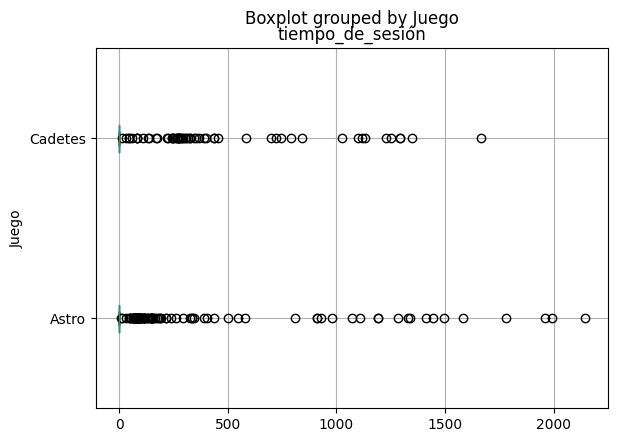

In [56]:
df_categorico.boxplot("tiempo_de_sesión", by="Juego", vert=False)

In [51]:
mod = ols('tiempo_de_sesión ~ Juego', data=df_categorico).fit()
anova_table = sm.stats.anova_lm(mod, typ=1)
print(anova_table)

              df        sum_sq       mean_sq        F    PR(>F)
Juego        1.0  1.142307e+04  11423.074614  1.06155  0.302904
Residual  5863.0  6.309028e+07  10760.749930      NaN       NaN
